# Ablation Study: Original vs Refined Methods

Demonstrates the structural defects of the original algorithms proposed by
Maliar, Maliar & Winant (2021) and the sensitivity of the refined BRM to
critic warm-start strength.

**Part A** runs the three original methods (LR without terminal value, ER
without target network, BRM-Joint with cold start and unnormalized Bellman
residual) under the exact same configuration as `01_basic_frictionless_benchmark`.
Training losses may decrease, but the validation diagnostics we trust (Euler
residual, lifetime reward, policy MAE) tell a different story.

**Part B** examines the refined BRM (decoupled actor/critic, normalized BR)
under three warm-start strengths to test how sensitive training is to the
early critic gradient field and whether different warm starts steer toward
different final policies.

---
# Section 0: Setup

In [1]:
import sys, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
from dataclasses import replace

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _REPO_ROOT = Path(_nb_file).parent.parent
else:
    _REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

from src.v2.evaluation import (
    build_action_grid_policy,
    evaluate_lifetime_reward,
    evaluate_policy_mae,
    load_manifest,
    load_method_bundle,
    load_solver_bundle,
    prepare_evaluation_run,
    restore_selected_snapshot,
    save_figure,
    save_manifest_sections,
    save_method_bundle,
    save_solver_bundle,
    save_plot_inputs,
    save_summary_rows,
)
from src.v2.data.generator import DataGenerator, DataGeneratorConfig
from src.v2.environments.basic_investment import (
    BasicInvestmentEnv, EconomicParams, ShockParams,
    compute_frictionless_policy,
)
from src.v2.networks.policy import PolicyNetwork
from src.v2.networks.state_value import StateValueNetwork
from src.v2.trainers.brm import train_brm
from src.v2.trainers.config import LRConfig, ERConfig, BRMConfig
from src.v2.trainers.core import evaluate_euler_residual
from src.v2.trainers.lr import train_lr
from src.v2.ablations.er_original import train_er_original
from src.v2.ablations.brm_joint import train_brm_joint
from src.v2.utils.seeding import fold_in_seed, seed_runtime

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.16.2
GPU available: False


In [2]:
# Run control
EXPERIMENT_NAME = "basic_frictionless"

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    from pathlib import Path as _Path
    _REPO_ROOT = _Path(_nb_file).parent.parent
else:
    from pathlib import Path as _Path
    _REPO_ROOT = _Path.cwd().parent
RESULTS_ROOT = str(_REPO_ROOT / "outputs" / "notebooks")

SAVE_RUN     = False
LOAD_RUN_DIR = None
RUN_TAG      = "part1-ablation"
RECOMPUTE_LOADED_METRICS = False

# Part A: original methods
PART_A_METHODS = ["LR-Orig", "ER-Orig", "BRM-Joint"]
# Part B: refined BRM sensitivity
PART_B_METHODS = ["BRM-Cold", "BRM-Weak", "BRM-Strong"]
ALL_METHODS    = PART_A_METHODS + PART_B_METHODS

METHOD_COLORS = {
    "LR-Orig":   "steelblue",
    "ER-Orig":   "darkorange",
    "BRM-Joint": "mediumorchid",
    "BRM-Cold":  "crimson",
    "BRM-Weak":  "goldenrod",
    "BRM-Strong":"seagreen",
}

RUN = prepare_evaluation_run(
    EXPERIMENT_NAME,
    save_run=SAVE_RUN,
    load_run_dir=LOAD_RUN_DIR,
    results_root=RESULTS_ROOT,
    run_tag=RUN_TAG,
)
print(f"Mode: {RUN['mode']}")
if RUN["run_dir"] is not None:
    print(f"Run dir: {RUN['run_dir']}")

Mode: memory


In [3]:
# Training profile: controls only computational cost.
# Switch to "FULL" for paper-quality results.
PROFILE = "FAST_DEBUG"

_PROFILES = {
    "FAST_DEBUG": dict(
        N_LAYERS=2, N_NEURONS=32,
        N_STEPS=300,  EVAL_INTERVAL=50,
    ),
    "FULL": dict(
        N_LAYERS=4, N_NEURONS=128,
        N_STEPS=4000, EVAL_INTERVAL=100,
    ),
}
assert PROFILE in _PROFILES, f"Unknown profile: {PROFILE!r}. Choose from {list(_PROFILES)}"
_p = _PROFILES[PROFILE]
print(f"Profile: {PROFILE} | net={_p['N_LAYERS']}L x {_p['N_NEURONS']}N | cap={_p['N_STEPS']:,} steps")

Profile: FAST_DEBUG | net=2L x 32N | cap=300 steps


In [4]:
# From profile
N_LAYERS       = _p["N_LAYERS"]
N_NEURONS      = _p["N_NEURONS"]
N_STEPS        = _p["N_STEPS"]
EVAL_INTERVAL  = _p["EVAL_INTERVAL"]

# Fixed — identical to 01_basic_frictionless_benchmark
CONVERGENCE_MONITOR   = "policy_mae"
CONVERGENCE_THRESHOLD = 2.0
THRESHOLD_PATIENCE    = 2
PLATEAU_PATIENCE      = None
N_PATHS              = 5000
HORIZON_DATA         = 256
MASTER_SEED          = (20, 26)
STRICT_REPRODUCIBILITY = False
LR_HORIZON           = 32

EVAL_HORIZON         = 128
EVAL_TRAJ_SAMPLES    = 2000
ANALYTIC_GAP_SAMPLES = 20000

print(f"Threshold stopping: {CONVERGENCE_MONITOR} <= {CONVERGENCE_THRESHOLD} for {THRESHOLD_PATIENCE} evals | cap={N_STEPS:,} steps")
print(f"Data: N_PATHS={N_PATHS}, HORIZON={HORIZON_DATA}, MASTER_SEED={MASTER_SEED}")

Threshold stopping: policy_mae <= 2.0 for 2 evals | cap=300 steps
Data: N_PATHS=5000, HORIZON=256, MASTER_SEED=(20, 26)


---
# Section 1: Environment & Data

In [5]:
baseline_params = EconomicParams(
    interest_rate=0.04,
    depreciation_rate=0.15,
    production_elasticity=0.7,
    cost_convex=0.0,
    cost_fixed=0.0,
)
shock_params = ShockParams(mu=0.0, rho=0.7, sigma=0.1)

env = BasicInvestmentEnv(econ_params=baseline_params, shock_params=shock_params)

print("BasicInvestmentEnv (frictionless baseline)")
print(f"  State dim:  {env.state_dim()}   (endo={env.endo_dim()}, exo={env.exo_dim()})")
print(f"  Action dim: {env.action_dim()}")
print(f"  Discount:   {env.discount():.4f}")
print(f"  k in [{env.k_min:.2f}, {env.k_max:.2f}]")
print(f"  z in [{env.z_min:.3f}, {env.z_max:.3f}]")

BasicInvestmentEnv (frictionless baseline)
  State dim:  2   (endo=1, exo=1)
  Action dim: 1
  Discount:   0.9615
  k in [19.63, 471.20]
  z in [0.657, 1.522]


In [6]:
gen_config = DataGeneratorConfig(
    n_paths=N_PATHS,
    horizon=HORIZON_DATA,
    master_seed=MASTER_SEED,
)
gen = DataGenerator(env, gen_config)

train_traj = gen.get_trajectory_dataset("train")
train_flat = gen.get_flattened_dataset("train")
val_traj   = gen.get_trajectory_dataset("val")
val_flat   = gen.get_flattened_dataset("val")

save_manifest_sections(
    RUN,
    setup={
        "master_seed":              list(MASTER_SEED),
        "strict_reproducibility":   STRICT_REPRODUCIBILITY,
    },
    data={
        "n_paths":     N_PATHS,
        "horizon":     HORIZON_DATA,
        "master_seed": list(MASTER_SEED),
    },
    env={"econ_params": baseline_params, "shock_params": shock_params},
)

print(f"Training trajectories: {train_traj['s_endo_0'].shape[0]} paths")
print(f"Training flat states:  {train_flat['s_endo'].shape[0]}")
print(f"Validation trajectories: {val_traj['s_endo_0'].shape[0]} paths")
print(f"Validation flat states:  {val_flat['s_endo'].shape[0]}")

Training trajectories: 5000 paths
Training flat states:  1280000
Validation trajectories: 5000 paths
Validation flat states:  1280000


---
# Section 2: Helpers

In [7]:
# Network factories

def derived_seed(*tokens):
    """Derive a deterministic child seed pair from MASTER_SEED for network init."""
    return fold_in_seed(MASTER_SEED, *tokens)


def make_policy_net(env, name="policy", seed=None):
    net = PolicyNetwork(
        state_dim=env.state_dim(),
        action_dim=env.action_dim(),
        **env.action_spec(),
        n_layers=N_LAYERS,
        n_neurons=N_NEURONS,
        seed=seed,
        name=name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


def make_value_net(env, name="value_net", seed=None):
    net = StateValueNetwork(
        state_dim=env.state_dim(),
        n_layers=N_LAYERS,
        n_neurons=N_NEURONS,
        seed=seed,
        name=name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


def take_dataset_head(dataset, n):
    return {k: v[:n] for k, v in dataset.items()}

In [8]:
# Evaluation utilities

def analytic_kprime(z):
    """Frictionless optimal next-period capital k'*(z), clipped to grid bounds."""
    return np.clip(
        compute_frictionless_policy(z, baseline_params, shock_params),
        env.k_min,
        env.k_max,
    )

def make_eval_callback(eval_env, eval_flat, eval_traj, analytic_dataset):
    def _callback(step, _env, policy, value_net, val_dataset):
        del step, value_net, val_dataset
        metrics = {
            "euler_residual_val":  evaluate_euler_residual(eval_env, policy, eval_flat),
            "lifetime_reward_val": evaluate_lifetime_reward(eval_env, policy, eval_traj, horizon=EVAL_HORIZON, n_samples=EVAL_TRAJ_SAMPLES),
        }
        try:
            metrics["policy_mae"] = evaluate_policy_mae(eval_env, policy, analytic_dataset)
        except NotImplementedError:
            pass
        return metrics
    return _callback


def auto_monitor(eval_env):
    """Return the highest-priority available convergence metric."""
    try:
        eval_env.analytical_policy(
            eval_env.sample_initial_states(1, seed=tf.constant([0, 0])))
        return "policy_mae"
    except NotImplementedError:
        pass
    try:
        eval_env.euler_residual(
            *[eval_env.sample_initial_states(1, seed=tf.constant([0, 0]))] * 4)
        return "euler_residual_val"
    except NotImplementedError:
        pass
    return "lifetime_reward_val"

In [9]:
# Checkpoint & plotting helpers

results = {}

def persist_figure(fig, filename):
    save_figure(RUN, fig, filename)


def persist_method(name):
    entry = results[name]
    save_method_bundle(
        RUN, name,
        result=entry.get("result"),
        weight_history=entry.get("weight_history"),
        checkpoint_metrics=entry.get("checkpoint_metrics"),
        selected=entry.get("selected"),
        extra_sections={"name": entry.get("name", name)},
    )


def evaluate_snapshots(name, results_dict, env, val_traj, analytic_dataset):
    """Read checkpoint metrics directly from the trainer history (no re-evaluation)."""
    del env, val_traj, analytic_dataset
    entry   = results_dict[name]
    history = entry["result"]["history"]
    metrics = {
        key: list(history[key])
        for key in ["step", "elapsed_sec",
                    "loss", "loss_br", "loss_foc",
                    "euler_residual_val", "lifetime_reward_val", "policy_mae"]
        if key in history
    }
    entry["checkpoint_metrics"] = metrics
    entry["checkpoint_index"]   = {step: idx for idx, step in enumerate(metrics["step"])}
    print(f"  {name}: {len(metrics['step'])} checkpoint metrics from trainer history")


def select_checkpoint(name, results_dict):
    """Select and restore the best policy snapshot."""
    entry       = results_dict[name]
    result      = entry["result"]
    metrics     = entry["checkpoint_metrics"]
    step_to_idx = entry["checkpoint_index"]

    if result["converged"] and result["stop_step"] in step_to_idx:
        selected_step, status = result["stop_step"], "converged"
    elif result["best_step"] is not None and result["best_step"] in step_to_idx:
        selected_step, status = result["best_step"], "not_converged"
    else:
        entry["selected"] = {
            "status": "no_data", "selected_step": None,
            "selected_euler": float("nan"), "selected_value": float("nan"),
            "selected_analytic_mae": float("nan"),
            "first_hit_step": result.get("threshold_step"),
            "first_hit_elapsed_sec": result.get("threshold_elapsed_sec"),
            "stop_step": result.get("stop_step"),
            "stop_elapsed_sec": result.get("stop_elapsed_sec"),
            "wall_time_sec": result["wall_time_sec"],
            "stop_reason": result.get("stop_reason"),
        }
        return

    idx = step_to_idx[selected_step]
    entry["selected"] = {
        "status": status,
        "selected_step": selected_step,
        "selected_elapsed_sec": metrics["elapsed_sec"][idx],
        "selected_euler": metrics["euler_residual_val"][idx],
        "selected_value": metrics["lifetime_reward_val"][idx],
        "selected_analytic_mae": metrics["policy_mae"][idx],
        "first_hit_step": result.get("threshold_step"),
        "first_hit_elapsed_sec": result.get("threshold_elapsed_sec"),
        "stop_step": result.get("stop_step"),
        "stop_elapsed_sec": result.get("stop_elapsed_sec"),
        "wall_time_sec": result["wall_time_sec"],
        "stop_reason": result.get("stop_reason"),
    }
    for step, weights in entry["weight_history"]:
        if step == selected_step:
            entry["policy"].set_weights(weights)
            entry["selected_weights"] = weights
            return
    raise ValueError(f"{name}: selected step {selected_step} missing from weight history")


def get_policy_slices(policy):
    """Compute k'(z) at k=k* and k'(k) at z=E[z] via env.endogenous_transition."""
    a_z = policy(s_at_kstar, training=False)
    a_k = policy(s_at_zmean, training=False)
    kp_z = env.endogenous_transition(
        s_at_kstar[:, :env.endo_dim()], a_z, s_at_kstar[:, env.endo_dim():]
    ).numpy().reshape(-1)
    kp_k = env.endogenous_transition(
        s_at_zmean[:, :env.endo_dim()], a_k, s_at_zmean[:, env.endo_dim():]
    ).numpy().reshape(-1)
    return kp_z, kp_k


def validate_single(label, kp_z, kp_k, color, save_name=None):
    corr = np.corrcoef(kp_z, kp_analytical_z)[0, 1]
    mae  = np.mean(np.abs(kp_z - kp_analytical_z))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(z_grid, kp_analytical_z, "k--", lw=2, alpha=0.8, label="Analytical")
    axes[0].plot(z_grid, kp_z, color=color, lw=1.5, label=label)
    axes[0].set_title(f"k'(z) at k=k*   corr={corr:.4f}, MAE={mae:.2f}", fontweight="bold")
    axes[0].set_xlabel("Productivity z"); axes[0].set_ylabel("Next capital k'")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].axhline(kp_analytical_ss, color="k", ls="--", lw=2, alpha=0.8,
                    label=f"Analytical k'={kp_analytical_ss:.1f}")
    axes[1].plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.5, label="45 line")
    axes[1].plot(k_grid, kp_k, color=color, lw=1.5, label=label)
    axes[1].set_title("k'(k) at z=E[z]   (should be flat)", fontweight="bold")
    axes[1].set_xlabel("Current capital k"); axes[1].set_ylabel("Next capital k'")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"{label} — Selected Checkpoint Validation",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    persist_figure(fig, save_name)
    plt.show()


def add_hit_marker(ax, entry, y_values, color, label):
    first_hit_step = entry["result"].get("threshold_step")
    if first_hit_step is None:
        return
    idx = entry["checkpoint_index"].get(first_hit_step)
    if idx is None:
        return
    ax.scatter(
        entry["checkpoint_metrics"]["elapsed_sec"][idx],
        y_values[idx],
        s=60, facecolors="none", edgecolors=color, linewidths=1.8, label=label,
    )

In [10]:
accuracy_flat = take_dataset_head(val_flat, ANALYTIC_GAP_SAMPLES)

n_grid = 500
z_grid = np.linspace(float(env.z_min), float(env.z_max), n_grid)
k_grid = np.linspace(float(env.k_min), float(env.k_max), n_grid)
k_star = float(env.k_star)
z_mean = float(np.exp(shock_params.mu))
delta  = baseline_params.delta

kp_analytical_z  = analytic_kprime(z_grid)
kp_analytical_ss = analytic_kprime(np.array([z_mean]))[0]

s_at_kstar = tf.constant(np.column_stack([np.full(n_grid, k_star), z_grid]),  dtype=tf.float32)
s_at_zmean = tf.constant(np.column_stack([k_grid, np.full(n_grid, z_mean)]), dtype=tf.float32)

save_plot_inputs(
    RUN, "slice_grids",
    {
        "z_grid": z_grid, "k_grid": k_grid,
        "k_star": [k_star], "z_mean": [z_mean],
        "kp_analytical_z": kp_analytical_z,
        "kp_analytical_ss": [kp_analytical_ss],
    },
)

analytic_value = evaluate_lifetime_reward(env, env.analytical_policy, val_traj, horizon=EVAL_HORIZON, n_samples=EVAL_TRAJ_SAMPLES)
print(f"Analytical lifetime reward: {analytic_value:.2f}")

Analytical lifetime reward: 425.90


---
# Part A — Original Methods (Maliar et al. 2021)

Run the three original algorithms under the **exact same** configuration as
`01_basic_frictionless_benchmark`.  Each method retains a single structural
defect relative to our refined version:

| Method | Structural Defect |
|--------|-------------------|
| **LR-Orig** | No terminal value correction — truncated BPTT undervalues long-horizon states |
| **ER-Orig** | No target network — both sides of the Euler equation shift every gradient step |
| **BRM-Joint** | Joint optimizer, no warm start, unnormalized BR — mixed BR/FOC gradients on policy |

In [11]:
# Part A trainer configurations

_monitor = auto_monitor(env) if CONVERGENCE_MONITOR == "auto" else CONVERGENCE_MONITOR

_common = dict(
    master_seed=MASTER_SEED,
    strict_reproducibility=STRICT_REPRODUCIBILITY,
    n_steps=N_STEPS,
    eval_interval=EVAL_INTERVAL,
    monitor=_monitor,
    mode="min",
    threshold=CONVERGENCE_THRESHOLD,
    threshold_patience=THRESHOLD_PATIENCE,
    plateau_patience=PLATEAU_PATIENCE,
)

# LR-Orig: truncated BPTT, no terminal value correction
lr_orig_config = LRConfig(
    **_common,
    horizon=LR_HORIZON,
    terminal_value=False,   # <-- the structural defect
)

# ER-Orig: single-network ER, no target policy, no Polyak
er_orig_config = ERConfig(**_common)

# BRM-Joint: joint update, cold start, unnormalized Bellman residual
brm_joint_config = BRMConfig(
    **_common,
    br_scale=1.0,           # <-- no normalization (original recipe)
    warm_start_steps=0,     # <-- cold start
    warm_start_epochs=0,
)

print("Part A configs (original methods):")
for label, cfg in [("LR-Orig", lr_orig_config), ("ER-Orig", er_orig_config), ("BRM-Joint", brm_joint_config)]:
    print(f"  {label:<12} n_steps={cfg.n_steps:,}  eval_interval={cfg.eval_interval}")

Part A configs (original methods):
  LR-Orig      n_steps=300  eval_interval=50
  ER-Orig      n_steps=300  eval_interval=50
  BRM-Joint    n_steps=300  eval_interval=50


In [12]:
if RUN["mode"] != "load":
    weight_history_lr_orig = []
    res_lr_orig = train_lr(
        env,
        make_policy_net(env, "policy_lr_orig", seed=derived_seed("training", "LR-Orig", "policy")),
        train_traj,
        val_flat,
        config=replace(lr_orig_config, weight_history=weight_history_lr_orig),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["LR-Orig"] = {
        "name": "LR-Orig",
        "result": res_lr_orig,
        "policy": res_lr_orig["policy"],
        "weight_history": weight_history_lr_orig,
    }

LR step     0 | loss=-326.0440 | policy_mae=139.171158 | elapsed=7.2s
LR step    50 | loss=-362.9367 | policy_mae=112.378937 | elapsed=8.7s
LR step   100 | loss=-354.6281 | policy_mae=59.921005 | elapsed=10.1s
LR step   150 | loss=-354.0811 | policy_mae=22.873363 | elapsed=11.6s
LR step   200 | loss=-361.4130 | policy_mae=14.470439 | elapsed=13.0s
LR step   250 | loss=-359.2340 | policy_mae=12.989816 | elapsed=14.7s
LR step   299 | loss=-361.2841 | policy_mae=12.116395 | elapsed=16.2s


In [13]:
if RUN["mode"] != "load":
    weight_history_er_orig = []
    res_er_orig = train_er_original(
        env,
        make_policy_net(env, "policy_er_orig", seed=derived_seed("training", "ER-Orig", "policy")),
        train_flat,
        val_flat,
        config=replace(er_orig_config, weight_history=weight_history_er_orig),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["ER-Orig"] = {
        "name": "ER-Orig",
        "result": res_er_orig,
        "policy": res_er_orig["policy"],
        "weight_history": weight_history_er_orig,
    }

ER-Orig step     0 | loss=0.002368 | policy_mae=139.174026 | elapsed=3.4s
ER-Orig step    50 | loss=0.001588 | policy_mae=92.008881 | elapsed=6.9s
ER-Orig step   100 | loss=0.000126 | policy_mae=10.987510 | elapsed=10.3s
ER-Orig step   150 | loss=0.000014 | policy_mae=4.889331 | elapsed=13.7s
ER-Orig step   200 | loss=-0.000020 | policy_mae=2.084330 | elapsed=17.2s
ER-Orig step   250 | loss=-0.000019 | policy_mae=1.708284 | elapsed=20.7s
ER-Orig step   299 | loss=-0.000043 | policy_mae=1.819568 | elapsed=24.2s | stop=converged


In [14]:
if RUN["mode"] != "load":
    weight_history_brm_joint = []
    res_brm_joint = train_brm_joint(
        env,
        make_policy_net(env, "policy_brm_joint", seed=derived_seed("training", "BRM-Joint", "policy")),
        make_value_net(env, "value_net_brm_joint", seed=derived_seed("training", "BRM-Joint", "value")),
        train_flat,
        val_flat,
        config=replace(brm_joint_config, weight_history=weight_history_brm_joint),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["BRM-Joint"] = {
        "name": "BRM-Joint",
        "result": res_brm_joint,
        "policy": res_brm_joint["policy"],
        "value_net": res_brm_joint["value_net"],
        "weight_history": weight_history_brm_joint,
    }

BRM-Joint step     0 | loss=2574.580566 | loss_br=2573.583740 | loss_foc=0.996736 | policy_mae=139.777847 | elapsed=3.3s
BRM-Joint step    50 | loss=105.203629 | loss_br=104.233978 | loss_foc=0.969651 | policy_mae=177.563797 | elapsed=7.7s
BRM-Joint step   100 | loss=4.949696 | loss_br=3.977568 | loss_foc=0.972128 | policy_mae=178.637360 | elapsed=12.2s
BRM-Joint step   150 | loss=3.890344 | loss_br=2.910532 | loss_foc=0.979812 | policy_mae=179.483047 | elapsed=16.8s
BRM-Joint step   200 | loss=4.489701 | loss_br=3.509918 | loss_foc=0.979782 | policy_mae=179.453918 | elapsed=21.3s
BRM-Joint step   250 | loss=3.856724 | loss_br=2.880847 | loss_foc=0.975877 | policy_mae=179.325821 | elapsed=25.9s
BRM-Joint step   299 | loss=5.252192 | loss_br=4.288172 | loss_foc=0.964020 | policy_mae=179.465790 | elapsed=30.6s


In [15]:
print("Evaluating Part A checkpoints...")
for name in PART_A_METHODS:
    evaluate_snapshots(name, results, env, val_traj, accuracy_flat)
    select_checkpoint(name, results)
    persist_method(name)

header = "Method     | Status          | Wall(s) | SelStep | Euler      | Value      | Policy MAE"
print()
print(header)
print("-" * len(header))
for name in PART_A_METHODS:
    sel = results[name]["selected"]
    print(
        f"{name:>10s} | {sel['status']:>15s} | {sel['wall_time_sec']:7.1f} | "
        f"{str(sel['selected_step']):>7s} | {sel['selected_euler']:10.6f} | "
        f"{sel['selected_value']:10.2f} | {sel['selected_analytic_mae']:10.4f}"
    )

Evaluating Part A checkpoints...
  LR-Orig: 7 checkpoint metrics from trainer history
  ER-Orig: 7 checkpoint metrics from trainer history
  BRM-Joint: 7 checkpoint metrics from trainer history

Method     | Status          | Wall(s) | SelStep | Euler      | Value      | Policy MAE
---------------------------------------------------------------------------------------
   LR-Orig |   not_converged |    16.2 |     299 |   0.016723 |     421.42 |    12.1164
   ER-Orig |       converged |    24.2 |     299 |   0.014611 |     425.82 |     1.8196
 BRM-Joint |   not_converged |    30.6 |       0 |   0.047724 |     372.26 |   139.7778


## A.1 Training Loss Curves

The training losses below are the objectives each method actually minimizes.
A decreasing loss does **not** guarantee the policy is improving — it may
simply mean the network is better at fitting its own (possibly biased)
objective.

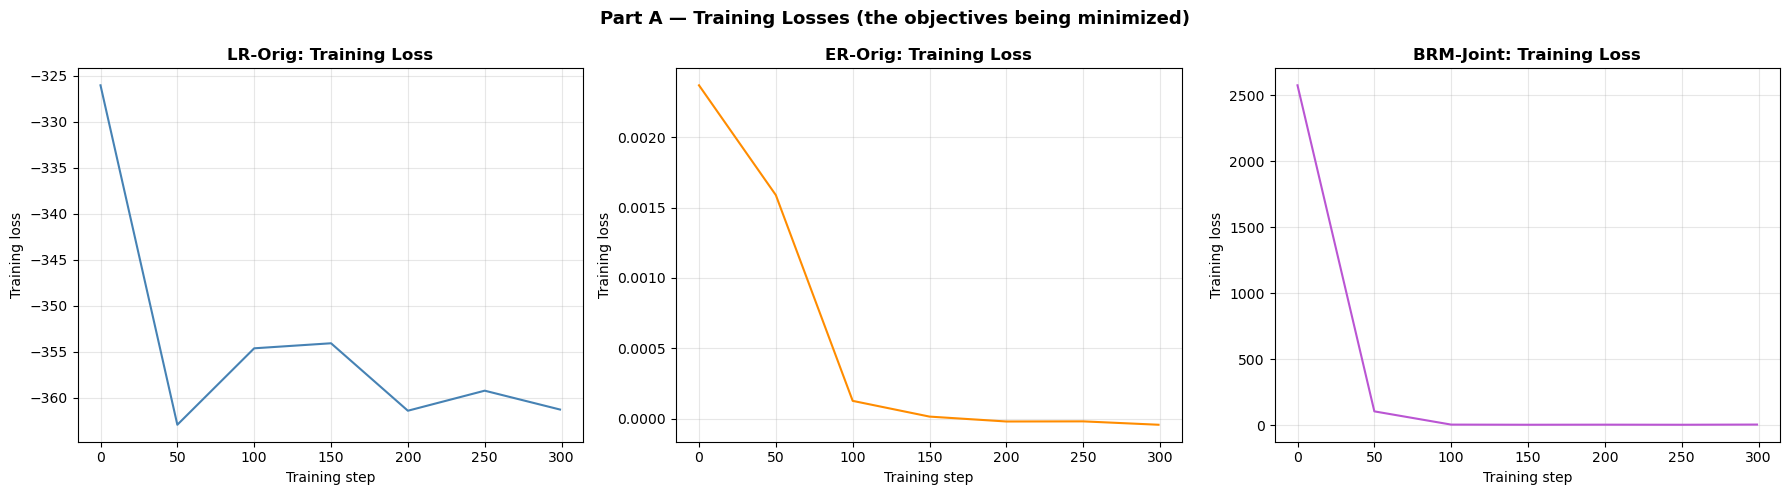

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, name in enumerate(PART_A_METHODS):
    ax = axes[ax_idx]
    m = results[name]["checkpoint_metrics"]
    ax.plot(m["step"], m.get("loss", []), color=METHOD_COLORS[name], lw=1.5)
    ax.set_xlabel("Training step")
    ax.set_ylabel("Training loss")
    ax.set_title(f"{name}: Training Loss", fontweight="bold")
    ax.grid(True, alpha=0.3)

fig.suptitle("Part A — Training Losses (the objectives being minimized)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "part_a_training_losses.png")
plt.show()

## A.2 Validation Diagnostics

These are the metrics we **trust**: Euler residual (equation error), lifetime
reward (economic value), and policy MAE (distance from analytical solution).
Unlike the training loss, these are computed on a held-out validation set and
measure actual policy quality.

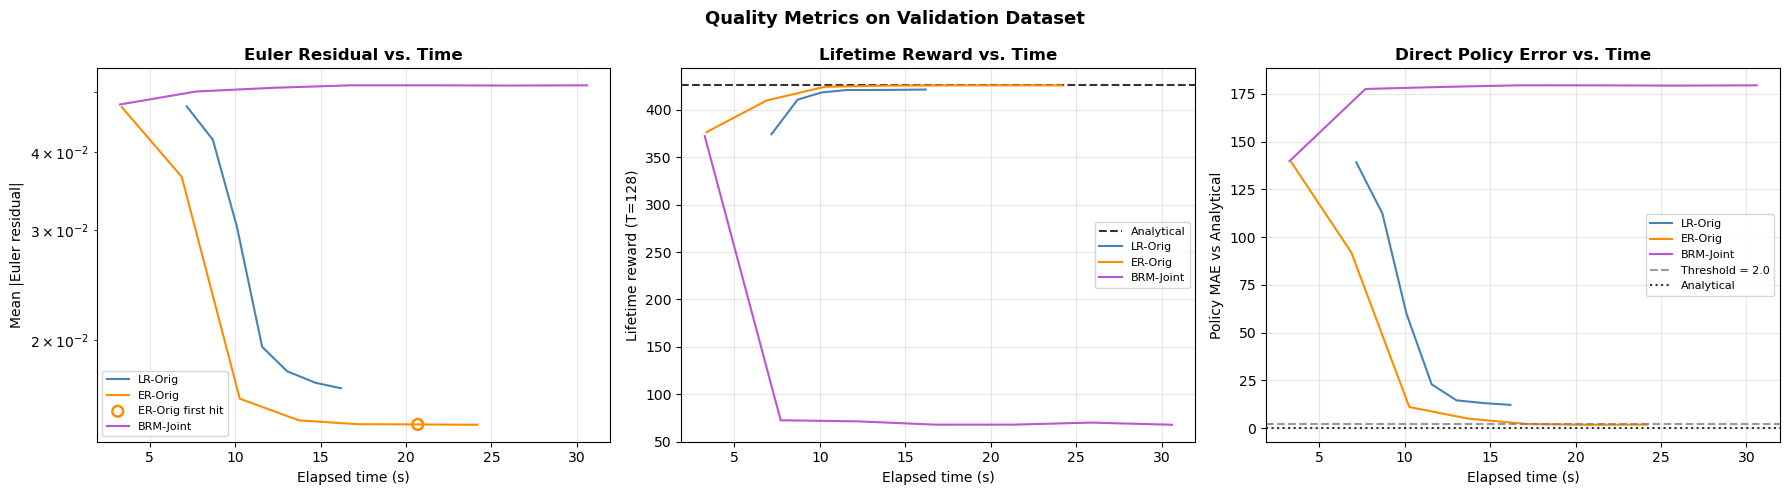

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for name in PART_A_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "euler_residual_val" in m:
        ax.plot(m["elapsed_sec"], m["euler_residual_val"],
                color=METHOD_COLORS[name], lw=1.5, label=name)
        add_hit_marker(ax, results[name], m["euler_residual_val"],
                       METHOD_COLORS[name], f"{name} first hit")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Mean |Euler residual|")
ax.set_title("Euler Residual vs. Time", fontweight="bold")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(analytic_value, color="black", lw=1.5, ls="--", alpha=0.8, label="Analytical")
for name in PART_A_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "lifetime_reward_val" in m:
        ax.plot(m["elapsed_sec"], m["lifetime_reward_val"],
                color=METHOD_COLORS[name], lw=1.5, label=name)
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel(f"Lifetime reward (T={EVAL_HORIZON})")
ax.set_title("Lifetime Reward vs. Time", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
for name in PART_A_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "policy_mae" in m:
        ax.plot(m["elapsed_sec"], m["policy_mae"],
                color=METHOD_COLORS[name], lw=1.5, label=name)
ax.axhline(CONVERGENCE_THRESHOLD, color="gray", lw=1.5, ls="--", alpha=0.8,
           label=f"Threshold = {CONVERGENCE_THRESHOLD}")
ax.axhline(0.0, color="black", lw=1.5, ls=":", alpha=0.8, label="Analytical")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Policy MAE vs Analytical")
ax.set_title("Direct Policy Error vs. Time", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("Quality Metrics on Validation Dataset",
             fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "part_a_validation_diagnostics.png")
plt.show()

## A.3 Policy Slice Validation

Visual comparison of the learned policy functions against the analytical
solution.  For a well-converged method, k'(z) should track the analytical
curve and k'(k) should be flat at k'=k*.

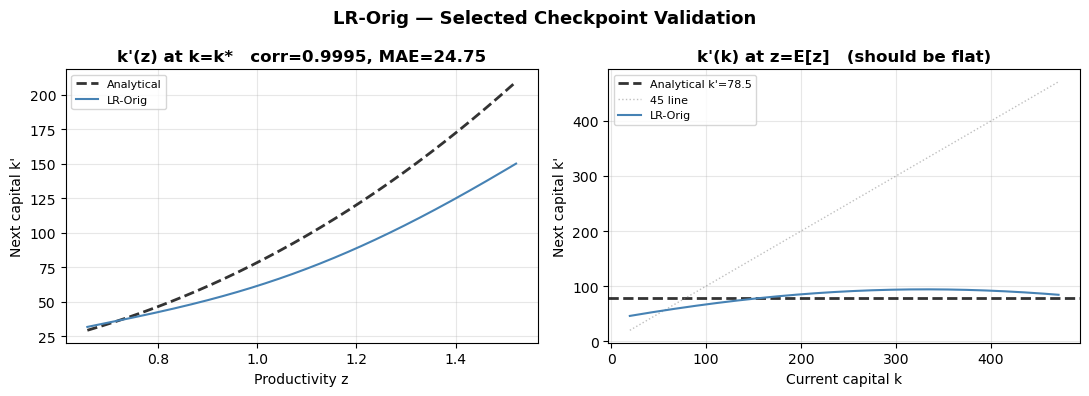

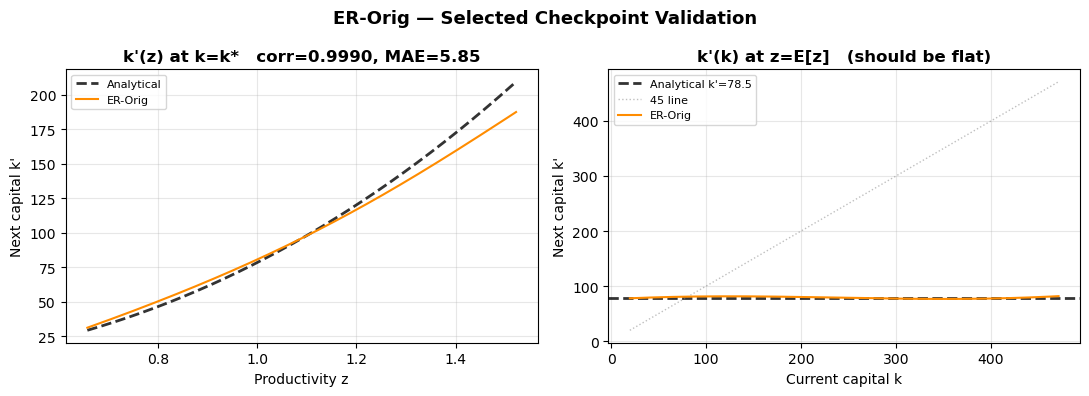

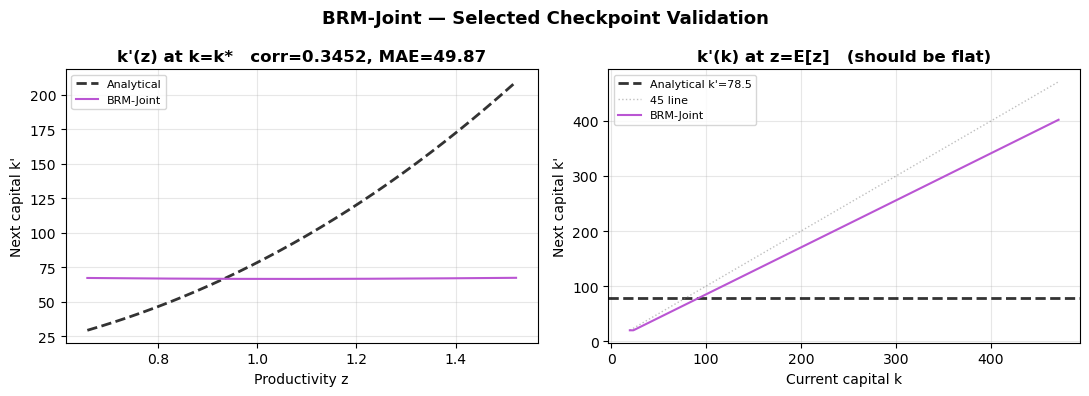

In [18]:
for name in PART_A_METHODS:
    kp_z, kp_k = get_policy_slices(results[name]["policy"])
    validate_single(name, kp_z, kp_k, METHOD_COLORS[name],
                    save_name=f"policy_validation_{name.lower().replace('-','_')}.png")

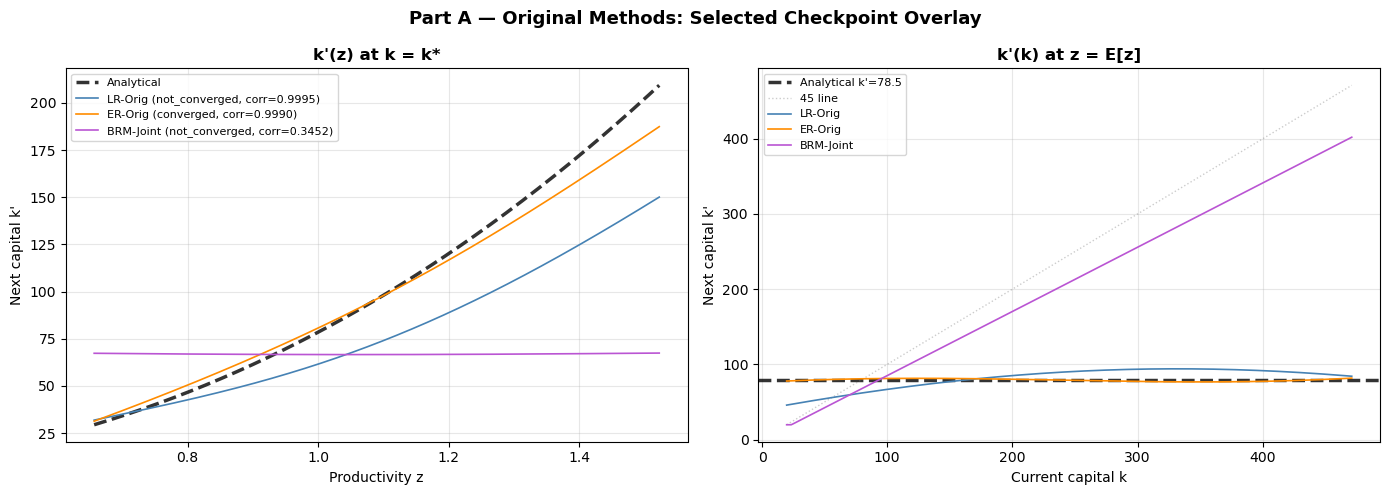

In [19]:
# Overlay all Part A methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(z_grid, kp_analytical_z, "k--", lw=2.5, alpha=0.8, label="Analytical")
for name in PART_A_METHODS:
    kp_z, _ = get_policy_slices(results[name]["policy"])
    corr = np.corrcoef(kp_z, kp_analytical_z)[0, 1]
    ax.plot(z_grid, kp_z, color=METHOD_COLORS[name], lw=1.2,
            label=f"{name} ({results[name]['selected']['status']}, corr={corr:.4f})")
ax.set_title("k'(z) at k = k*", fontweight="bold")
ax.set_xlabel("Productivity z"); ax.set_ylabel("Next capital k'")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(kp_analytical_ss, color="k", ls="--", lw=2.5,
           alpha=0.8, label=f"Analytical k'={kp_analytical_ss:.1f}")
ax.plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.4, label="45 line")
for name in PART_A_METHODS:
    _, kp_k = get_policy_slices(results[name]["policy"])
    ax.plot(k_grid, kp_k, color=METHOD_COLORS[name], lw=1.2, label=name)
ax.set_title("k'(k) at z = E[z]", fontweight="bold")
ax.set_xlabel("Current capital k"); ax.set_ylabel("Next capital k'")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("Part A — Original Methods: Selected Checkpoint Overlay",
             fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "part_a_overlay.png")
plt.show()

---
# Part B — Refined BRM: Warm-Start Sensitivity

The refined BRM uses decoupled actor/critic updates and normalized Bellman
residual (`br_scale = 1 / reward_scale`).  This section tests how sensitive
training is to the quality of the initial critic gradient field:

| Run | Warm-Start | Effective Steps | Intent |
|-----|-----------|-----------------|--------|
| **BRM-Cold** | 0 | 0 | Critic starts random — FOC gradients are initially garbage |
| **BRM-Weak** | 1 epoch | ~5,000 | Critic gets one full pass — rough but directional |
| **BRM-Strong** | 5 epochs | ~25,000 | Critic well-fitted — tests whether extra warmth changes the final basin |

In [20]:
# Part B: refined BRM with varying warm-start strength
# All use normalized BR (br_scale = 1/reward_scale) and decoupled updates.
# Warm start target is internally built:
# v_target = env.terminal_value(s_endo)   # = r(k, z̄, δk) / (1-γ)
# Note: This target itself is NOT anaytical solution, it is a deterministic approximation to provide correct gradient direction

_brm_common = dict(
    **_common,
    br_scale=1.0 / env.reward_scale(),
)

brm_cold_config = BRMConfig(
    **_brm_common,
    warm_start_steps=0,
    warm_start_epochs=0,
)

brm_weak_config = BRMConfig(
    **_brm_common,
    warm_start_steps=0,
    warm_start_epochs=1,      # one full pass through the data
)

brm_strong_config = BRMConfig(
    **_brm_common,
    warm_start_steps=0,
    warm_start_epochs=5,      # five full passes through the data
)

print(f"BRM reward_scale = {env.reward_scale():.4f}  =>  br_scale = {1.0/env.reward_scale():.6f}")
print(f"Flattened dataset size: {train_flat['s_endo'].shape[0]:,}")
print(f"  BRM-Cold:   warm_start = 0 steps")
print(f"  BRM-Weak:   warm_start = 1 epoch")
print(f"  BRM-Strong: warm_start = 5 epochs")

BRM reward_scale = 0.0041  =>  br_scale = 245.176132
Flattened dataset size: 1,280,000
  BRM-Cold:   warm_start = 0 steps
  BRM-Weak:   warm_start = 1 epoch
  BRM-Strong: warm_start = 5 epochs


In [21]:
if RUN["mode"] != "load":
    weight_history_brm_cold = []
    res_brm_cold = train_brm(
        env,
        make_policy_net(env, "policy_brm_cold", seed=derived_seed("training", "BRM-Cold", "policy")),
        make_value_net(env, "value_net_brm_cold", seed=derived_seed("training", "BRM-Cold", "value")),
        train_flat,
        val_flat,
        config=replace(brm_cold_config, weight_history=weight_history_brm_cold),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["BRM-Cold"] = {
        "name": "BRM-Cold",
        "result": res_brm_cold,
        "policy": res_brm_cold["policy"],
        "value_net": res_brm_cold["value_net"],
        "weight_history": weight_history_brm_cold,
    }

BRM step     0 | loss=1.044309 | loss_br=0.044904 | loss_foc=0.999405 | policy_mae=138.360443 | elapsed=3.3s
BRM step    50 | loss=1.071200 | loss_br=0.083148 | loss_foc=0.988052 | policy_mae=182.721588 | elapsed=8.1s
BRM step   100 | loss=1.136551 | loss_br=0.195456 | loss_foc=0.941095 | policy_mae=214.507355 | elapsed=12.9s
BRM step   150 | loss=1.087206 | loss_br=0.232341 | loss_foc=0.854865 | policy_mae=152.147797 | elapsed=17.8s
BRM step   200 | loss=0.857268 | loss_br=0.199688 | loss_foc=0.657580 | policy_mae=153.609940 | elapsed=22.5s
BRM step   250 | loss=0.490820 | loss_br=0.151656 | loss_foc=0.339164 | policy_mae=156.300888 | elapsed=27.3s
BRM step   299 | loss=0.130911 | loss_br=0.073770 | loss_foc=0.057142 | policy_mae=160.208649 | elapsed=32.2s


In [22]:
if RUN["mode"] != "load":
    weight_history_brm_weak = []
    res_brm_weak = train_brm(
        env,
        make_policy_net(env, "policy_brm_weak", seed=derived_seed("training", "BRM-Weak", "policy")),
        make_value_net(env, "value_net_brm_weak", seed=derived_seed("training", "BRM-Weak", "value")),
        train_flat,
        val_flat,
        config=replace(brm_weak_config, weight_history=weight_history_brm_weak),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["BRM-Weak"] = {
        "name": "BRM-Weak",
        "result": res_brm_weak,
        "policy": res_brm_weak["policy"],
        "value_net": res_brm_weak["value_net"],
        "weight_history": weight_history_brm_weak,
    }

  warm-start step    0 | MSE=52419.46
  warm-start step   50 | MSE=54425.67
  warm-start step  100 | MSE=48788.39
  warm-start step  150 | MSE=49421.34
  warm-start step  200 | MSE=43052.60
  warm-start step  250 | MSE=35539.97
  warm-start step  300 | MSE=25697.32
  warm-start step  350 | MSE=15966.47
  warm-start step  400 | MSE=10770.52
  warm-start step  450 | MSE=6935.07
  warm-start step  500 | MSE=5736.01
  warm-start step  550 | MSE=5331.70
  warm-start step  600 | MSE=4078.61
  warm-start step  650 | MSE=3579.14
  warm-start step  700 | MSE=3320.58
  warm-start step  750 | MSE=2723.65
  warm-start step  800 | MSE=2650.86
  warm-start step  850 | MSE=2175.07
  warm-start step  900 | MSE=1723.92
  warm-start step  950 | MSE=1644.60
  warm-start step 1000 | MSE=1162.97
  warm-start step 1050 | MSE=1003.37
  warm-start step 1100 | MSE=872.34
  warm-start step 1150 | MSE=704.88
  warm-start step 1200 | MSE=440.17
  warm-start step 1250 | MSE=328.23
  warm-start step 1300 | MSE=222.

In [23]:
if RUN["mode"] != "load":
    weight_history_brm_strong = []
    res_brm_strong = train_brm(
        env,
        make_policy_net(env, "policy_brm_strong", seed=derived_seed("training", "BRM-Strong", "policy")),
        make_value_net(env, "value_net_brm_strong", seed=derived_seed("training", "BRM-Strong", "value")),
        train_flat,
        val_flat,
        config=replace(brm_strong_config, weight_history=weight_history_brm_strong),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["BRM-Strong"] = {
        "name": "BRM-Strong",
        "result": res_brm_strong,
        "policy": res_brm_strong["policy"],
        "value_net": res_brm_strong["value_net"],
        "weight_history": weight_history_brm_strong,
    }

  warm-start step    0 | MSE=52405.43
  warm-start step   50 | MSE=54395.09
  warm-start step  100 | MSE=48635.49
  warm-start step  150 | MSE=48411.69
  warm-start step  200 | MSE=40220.89
  warm-start step  250 | MSE=30476.46
  warm-start step  300 | MSE=20876.49
  warm-start step  350 | MSE=14042.36
  warm-start step  400 | MSE=9059.33
  warm-start step  450 | MSE=6278.08
  warm-start step  500 | MSE=4877.90
  warm-start step  550 | MSE=4747.46
  warm-start step  600 | MSE=3683.42
  warm-start step  650 | MSE=3585.78
  warm-start step  700 | MSE=3237.46
  warm-start step  750 | MSE=2748.69
  warm-start step  800 | MSE=2888.40
  warm-start step  850 | MSE=2312.86
  warm-start step  900 | MSE=1904.82
  warm-start step  950 | MSE=1471.41
  warm-start step 1000 | MSE=1312.16
  warm-start step 1050 | MSE=933.48
  warm-start step 1100 | MSE=888.91
  warm-start step 1150 | MSE=620.37
  warm-start step 1200 | MSE=383.22
  warm-start step 1250 | MSE=314.43
  warm-start step 1300 | MSE=230.63

In [24]:
print("Evaluating Part B checkpoints...")
for name in PART_B_METHODS:
    evaluate_snapshots(name, results, env, val_traj, accuracy_flat)
    select_checkpoint(name, results)
    persist_method(name)

header = "Method      | Status          | Wall(s) | SelStep | Euler      | Value      | Policy MAE"
print()
print(header)
print("-" * len(header))
for name in PART_B_METHODS:
    sel = results[name]["selected"]
    print(
        f"{name:>11s} | {sel['status']:>15s} | {sel['wall_time_sec']:7.1f} | "
        f"{str(sel['selected_step']):>7s} | {sel['selected_euler']:10.6f} | "
        f"{sel['selected_value']:10.2f} | {sel['selected_analytic_mae']:10.4f}"
    )

Evaluating Part B checkpoints...
  BRM-Cold: 7 checkpoint metrics from trainer history
  BRM-Weak: 7 checkpoint metrics from trainer history
  BRM-Strong: 7 checkpoint metrics from trainer history

Method      | Status          | Wall(s) | SelStep | Euler      | Value      | Policy MAE
----------------------------------------------------------------------------------------
   BRM-Cold |   not_converged |    32.2 |       0 |   0.047367 |     373.70 |   138.3604
   BRM-Weak |   not_converged |    36.7 |      50 |   0.024325 |     413.25 |    39.6895
 BRM-Strong |   not_converged |    54.4 |     100 |   0.021990 |     418.05 |    30.0214


## B.1 Training Curves

Bellman residual loss (L_BR) and FOC loss (L_FOC) for the three refined BRM
variants.  Compare how the warm-start quality affects early training dynamics.

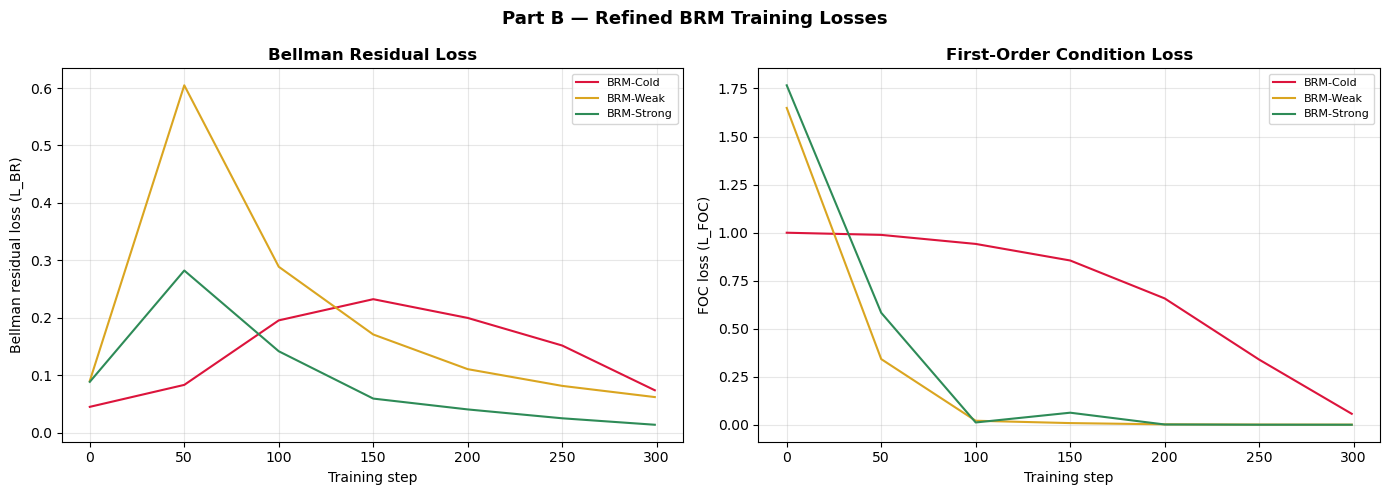

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name in PART_B_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "loss_br" in m:
        ax.plot(m["step"], m["loss_br"], color=METHOD_COLORS[name], lw=1.5, label=name)
ax.set_xlabel("Training step")
ax.set_ylabel("Bellman residual loss (L_BR)")
ax.set_title("Bellman Residual Loss", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for name in PART_B_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "loss_foc" in m:
        ax.plot(m["step"], m["loss_foc"], color=METHOD_COLORS[name], lw=1.5, label=name)
ax.set_xlabel("Training step")
ax.set_ylabel("FOC loss (L_FOC)")
ax.set_title("First-Order Condition Loss", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("Part B — Refined BRM Training Losses",
             fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "part_b_training_losses.png")
plt.show()

## B.2 Validation Diagnostics

Same three trusted metrics as Part A, now comparing the three warm-start
strengths.  Key question: does a cold start converge at all, or does the
refined structure compensate?

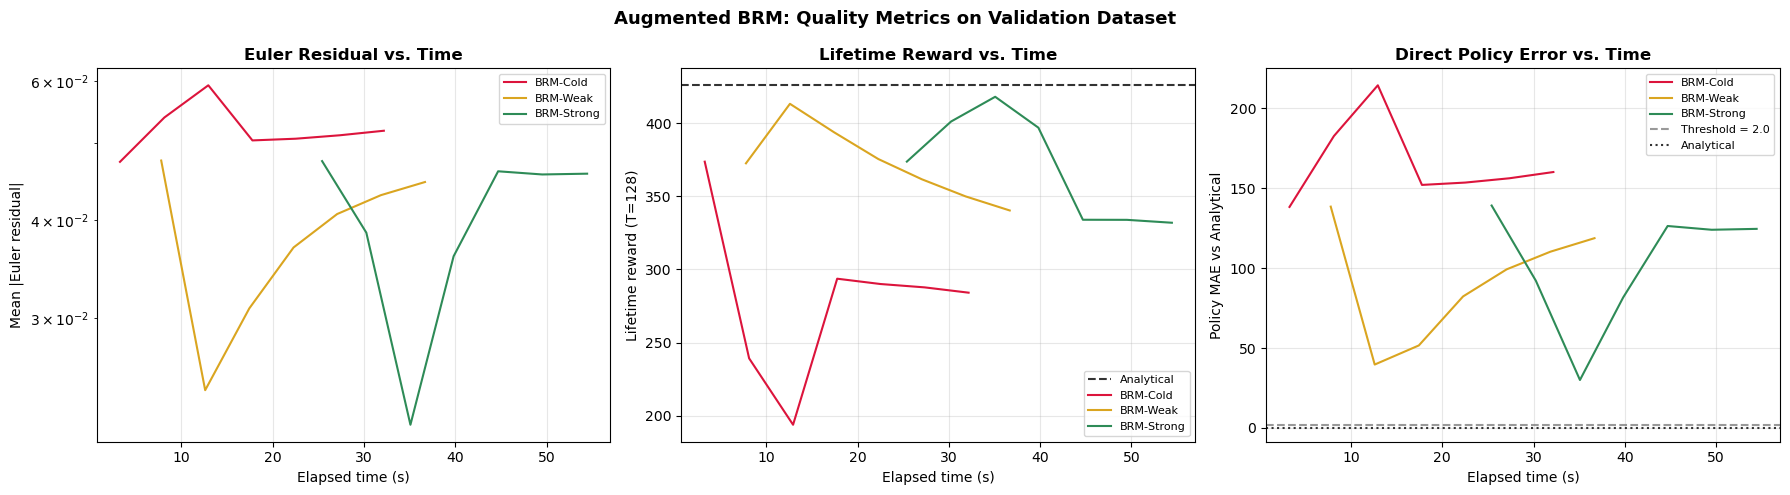

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for name in PART_B_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "euler_residual_val" in m:
        ax.plot(m["elapsed_sec"], m["euler_residual_val"],
                color=METHOD_COLORS[name], lw=1.5, label=name)
        add_hit_marker(ax, results[name], m["euler_residual_val"],
                       METHOD_COLORS[name], f"{name} first hit")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Mean |Euler residual|")
ax.set_title("Euler Residual vs. Time", fontweight="bold")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(analytic_value, color="black", lw=1.5, ls="--", alpha=0.8, label="Analytical")
for name in PART_B_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "lifetime_reward_val" in m:
        ax.plot(m["elapsed_sec"], m["lifetime_reward_val"],
                color=METHOD_COLORS[name], lw=1.5, label=name)
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel(f"Lifetime reward (T={EVAL_HORIZON})")
ax.set_title("Lifetime Reward vs. Time", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
for name in PART_B_METHODS:
    m = results[name]["checkpoint_metrics"]
    if "policy_mae" in m:
        ax.plot(m["elapsed_sec"], m["policy_mae"],
                color=METHOD_COLORS[name], lw=1.5, label=name)
ax.axhline(CONVERGENCE_THRESHOLD, color="gray", lw=1.5, ls="--", alpha=0.8,
           label=f"Threshold = {CONVERGENCE_THRESHOLD}")
ax.axhline(0.0, color="black", lw=1.5, ls=":", alpha=0.8, label="Analytical")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Policy MAE vs Analytical")
ax.set_title("Direct Policy Error vs. Time", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("Augmented BRM: Quality Metrics on Validation Dataset",
             fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "part_b_validation_diagnostics.png")
plt.show()

## B.3 Policy Slice Comparison

Do different warm-start strengths steer the policy into different basins, or
do they all converge to the same solution?

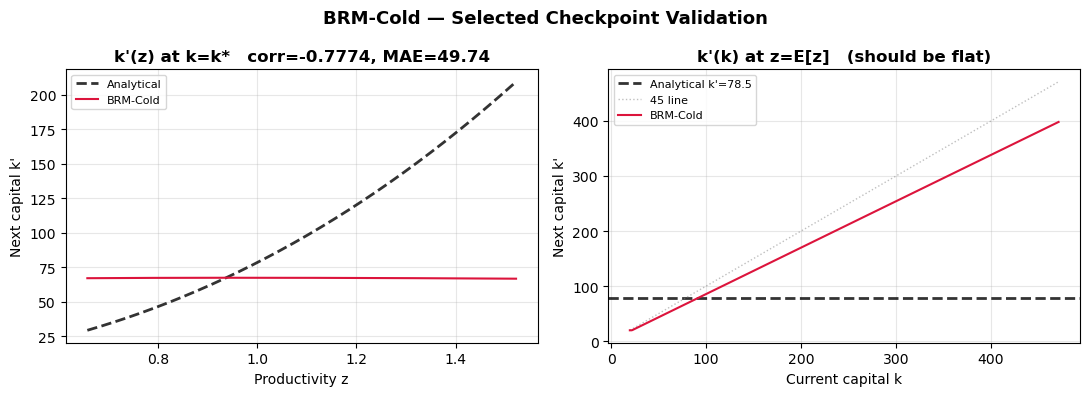

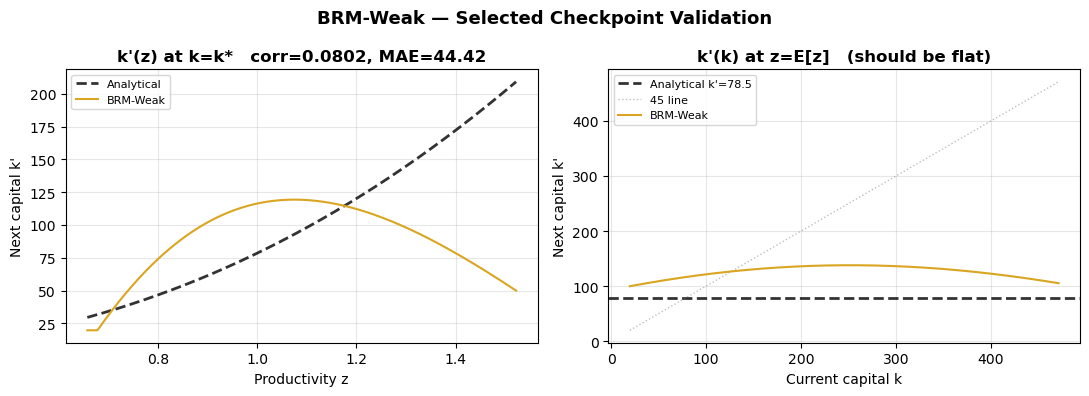

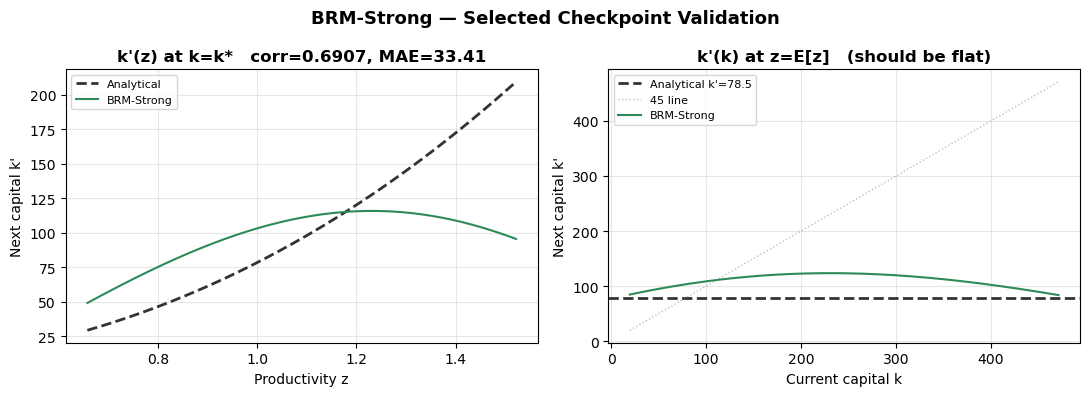

In [27]:
for name in PART_B_METHODS:
    kp_z, kp_k = get_policy_slices(results[name]["policy"])
    validate_single(name, kp_z, kp_k, METHOD_COLORS[name],
                    save_name=f"policy_validation_{name.lower().replace('-','_')}.png")

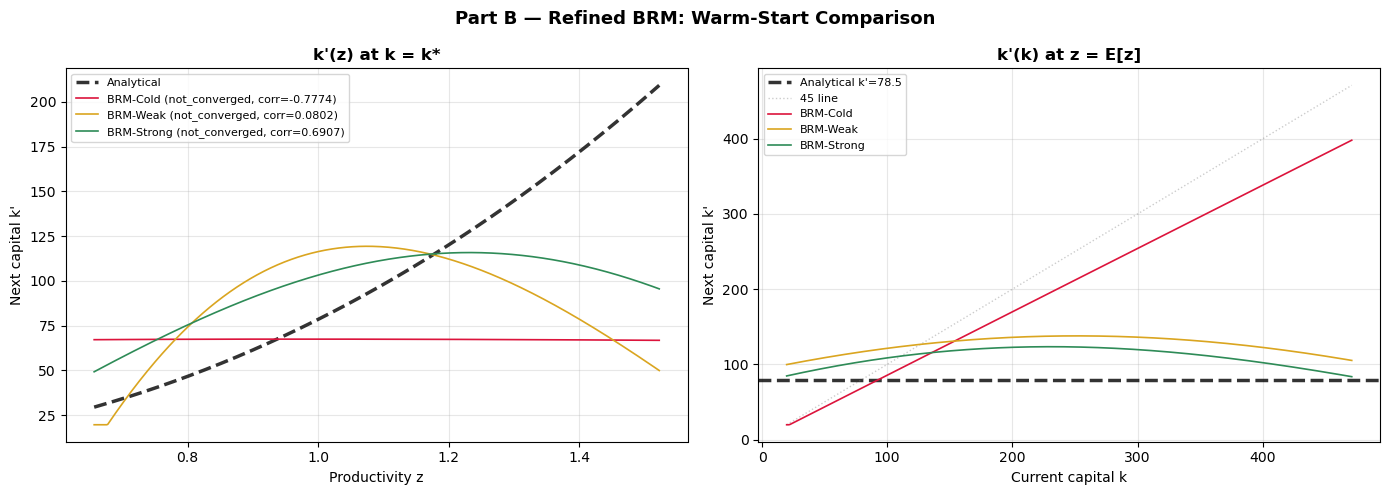

In [28]:
# Overlay all Part B methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(z_grid, kp_analytical_z, "k--", lw=2.5, alpha=0.8, label="Analytical")
for name in PART_B_METHODS:
    kp_z, _ = get_policy_slices(results[name]["policy"])
    corr = np.corrcoef(kp_z, kp_analytical_z)[0, 1]
    ax.plot(z_grid, kp_z, color=METHOD_COLORS[name], lw=1.2,
            label=f"{name} ({results[name]['selected']['status']}, corr={corr:.4f})")
ax.set_title("k'(z) at k = k*", fontweight="bold")
ax.set_xlabel("Productivity z"); ax.set_ylabel("Next capital k'")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(kp_analytical_ss, color="k", ls="--", lw=2.5,
           alpha=0.8, label=f"Analytical k'={kp_analytical_ss:.1f}")
ax.plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.4, label="45 line")
for name in PART_B_METHODS:
    _, kp_k = get_policy_slices(results[name]["policy"])
    ax.plot(k_grid, kp_k, color=METHOD_COLORS[name], lw=1.2, label=name)
ax.set_title("k'(k) at z = E[z]", fontweight="bold")
ax.set_xlabel("Current capital k"); ax.set_ylabel("Next capital k'")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("Part B — Refined BRM: Warm-Start Comparison",
             fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "part_b_overlay.png")
plt.show()

---
# Combined Summary

In [29]:
header = "Method      | Status          | Corr(k'z)  | MAE(k'z)  | MAE(k'k)  | Euler Res  | Lifetime V | Policy MAE | Cost(s)"
print(header)
print("-" * len(header))

summary_rows = []
for name in ALL_METHODS:
    kp_z, kp_k = get_policy_slices(results[name]["policy"])
    corr = np.corrcoef(kp_z, kp_analytical_z)[0, 1]
    mae_z = np.mean(np.abs(kp_z - kp_analytical_z))
    mae_k = np.mean(np.abs(kp_k - kp_analytical_ss))
    sel = results[name]["selected"]
    print(
        f"{name:>11s} | {sel['status']:<15s} | {corr:10.6f} | {mae_z:9.3f} | {mae_k:9.3f} | "
        f"{sel['selected_euler']:10.6f} | {sel['selected_value']:9.2f} | {sel['selected_analytic_mae']:10.4f} | "
        f"{sel['wall_time_sec']:7.1f}"
    )
    summary_rows.append({
        "method": name,
        "status": sel["status"],
        "corr_kprime_z": corr,
        "mae_kprime_z": mae_z,
        "mae_kprime_k": mae_k,
        "euler_residual": sel["selected_euler"],
        "lifetime_reward_val": sel["selected_value"],
        "analytic_kprime_mae": sel["selected_analytic_mae"],
        "cost_sec": sel["wall_time_sec"],
    })

save_summary_rows(RUN, summary_rows, filename="summary.csv")

Method      | Status          | Corr(k'z)  | MAE(k'z)  | MAE(k'k)  | Euler Res  | Lifetime V | Policy MAE | Cost(s)
-------------------------------------------------------------------------------------------------------------------
    LR-Orig | not_converged   |   0.999535 |    24.745 |    12.353 |   0.016723 |    421.42 |    12.1164 |    16.2
    ER-Orig | converged       |   0.998989 |     5.853 |     1.538 |   0.014611 |    425.82 |     1.8196 |    24.2
  BRM-Joint | not_converged   |   0.345181 |    49.868 |   140.716 |   0.047724 |    372.26 |   139.7778 |    30.6
   BRM-Cold | not_converged   |  -0.777408 |    49.741 |   139.342 |   0.047367 |    373.70 |   138.3604 |    32.2
   BRM-Weak | not_converged   |   0.080232 |    44.415 |    47.267 |   0.024325 |    413.25 |    39.6895 |    36.7
 BRM-Strong | not_converged   |   0.690713 |    33.411 |    31.306 |   0.021990 |    418.05 |    30.0214 |    54.4
